In [1]:
#Tratamiento de datos
import pandas as pd

import sys
sys.path.append('../')

from SRC import sp_visualizaciones_eda as sv
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_no_nulos=pd.read_csv("../datos/df_data_no_nulos.csv")

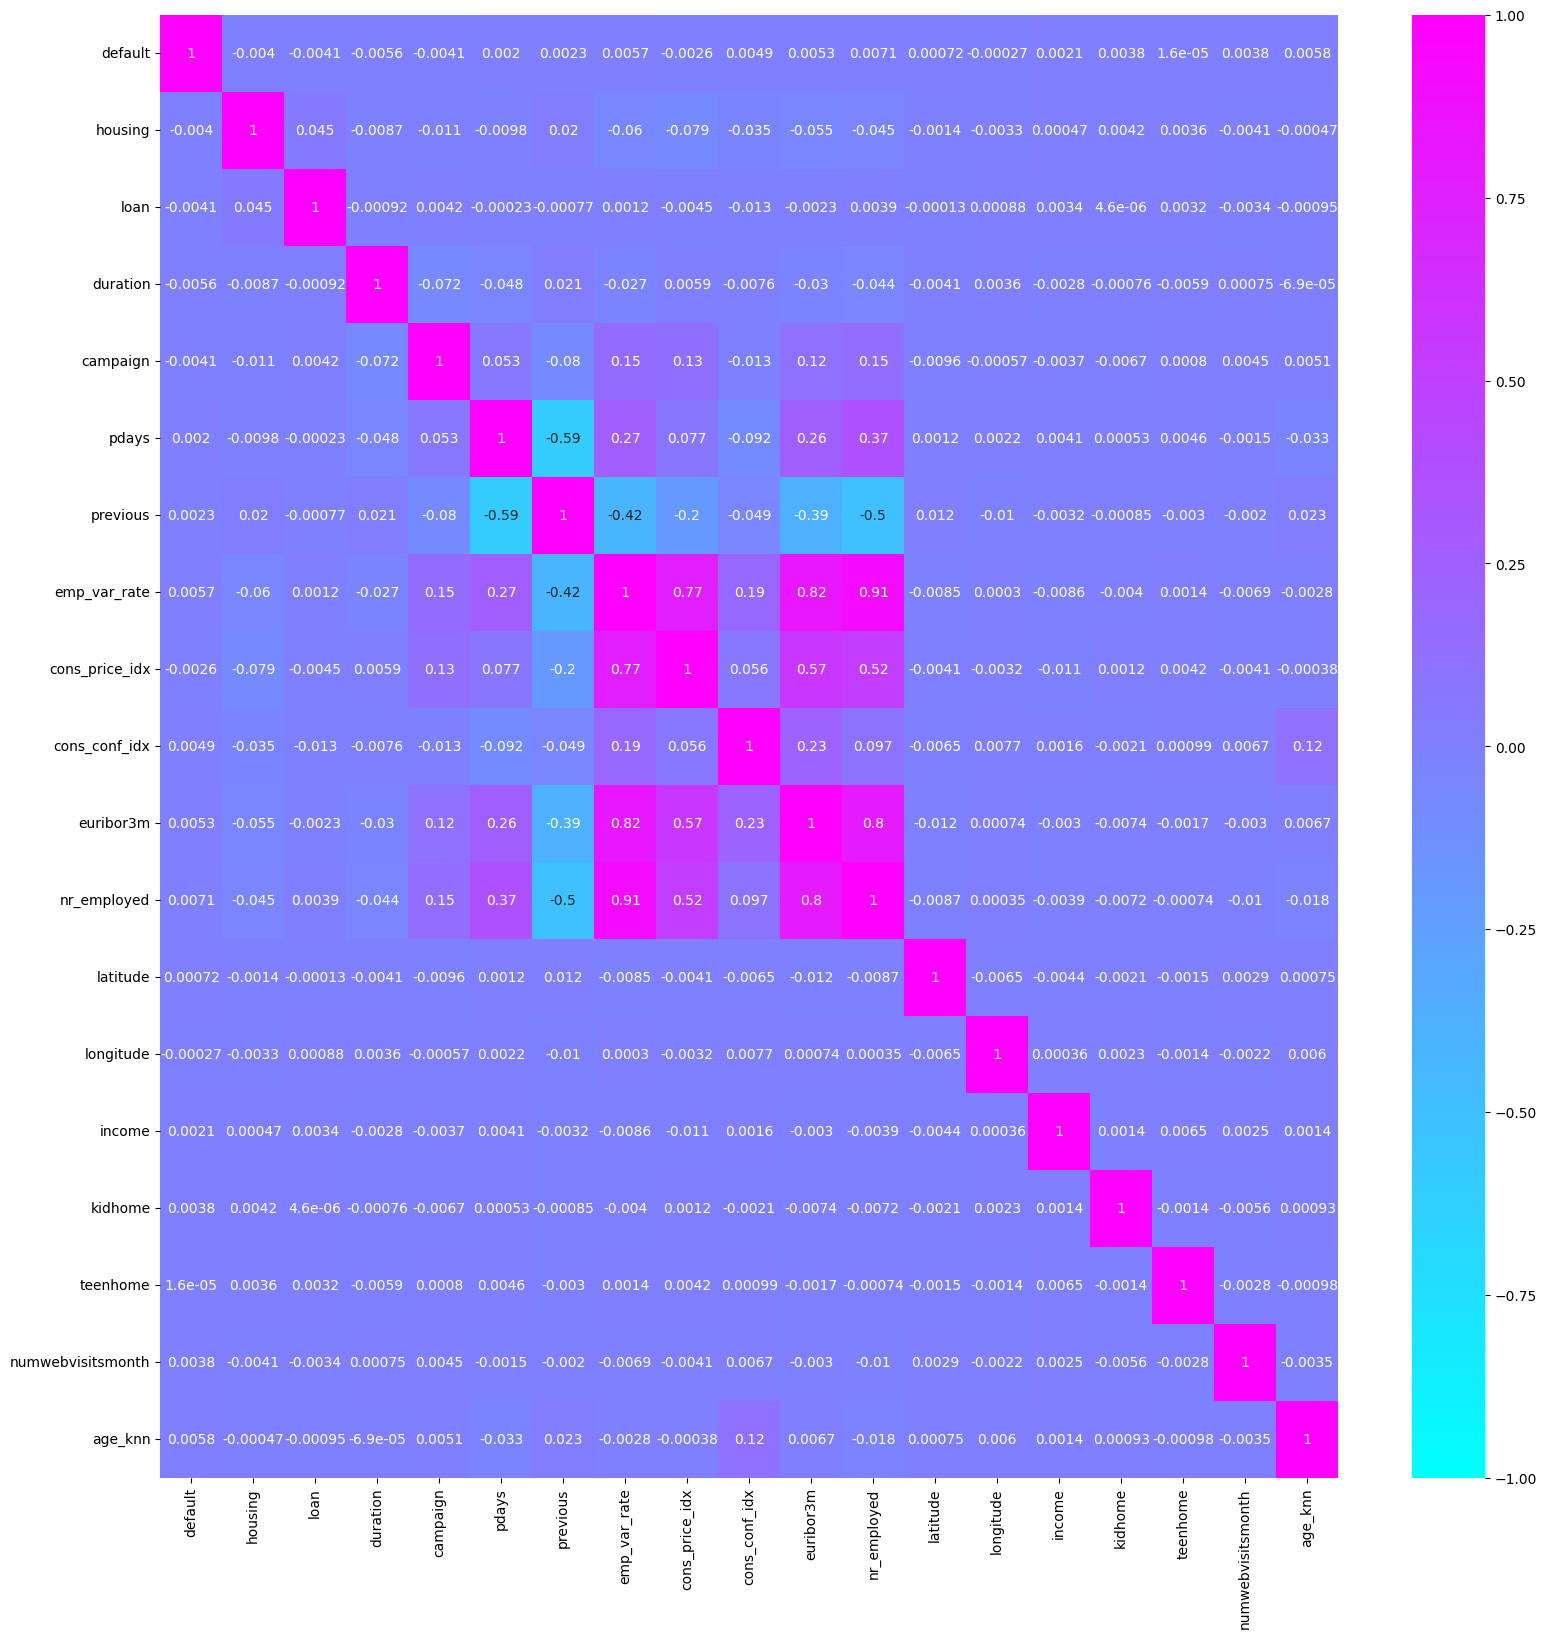

In [3]:
sv.matriz_correlacion(df_no_nulos)

### Relaciones cruzadas

In [4]:
df_no_nulos.columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp_var_rate',
       'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed',
       'subscription_prod', 'date_contact', 'latitude', 'longitude', 'income',
       'kidhome', 'teenhome', 'dt_customer', 'numwebvisitsmonth', 'id',
       'default_str', 'housing_str', 'loan_str', 'age_knn'],
      dtype='object')

### COLUMNAS NUMERICAS

In [5]:
col_num = 'age_knn'
cols_num = df_no_nulos.select_dtypes(include='number').columns
cols_num

Index(['default', 'housing', 'loan', 'duration', 'campaign', 'pdays',
       'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx',
       'euribor3m', 'nr_employed', 'latitude', 'longitude', 'income',
       'kidhome', 'teenhome', 'numwebvisitsmonth', 'age_knn'],
      dtype='object')

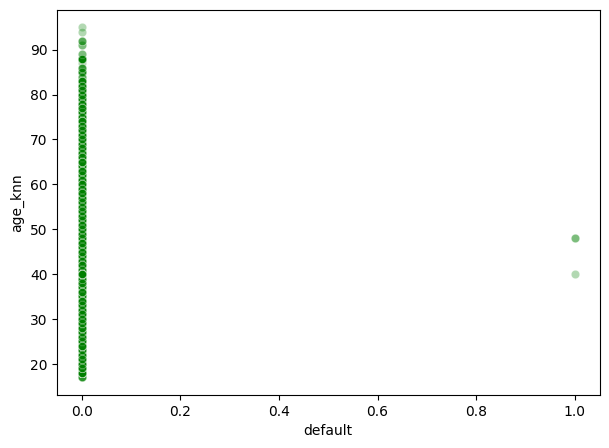

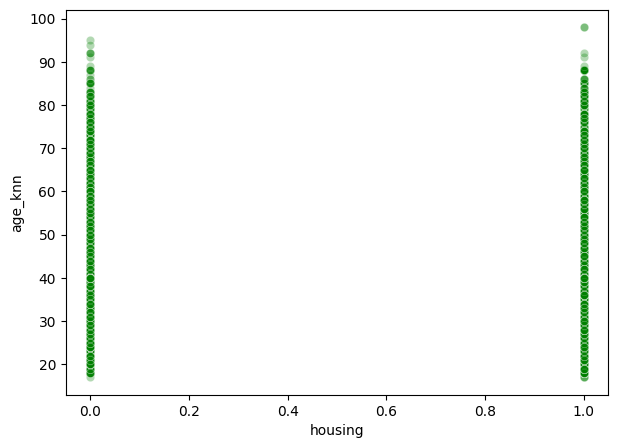

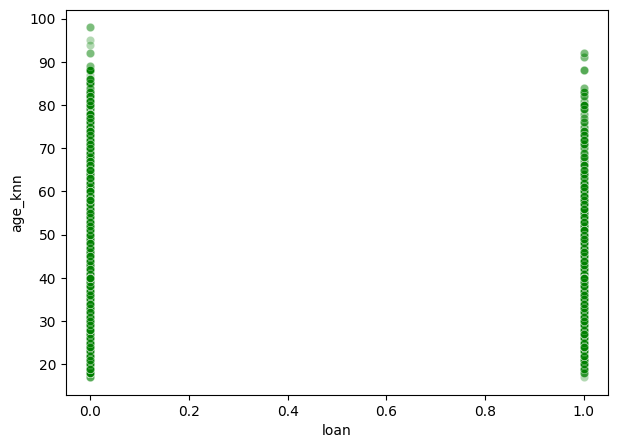

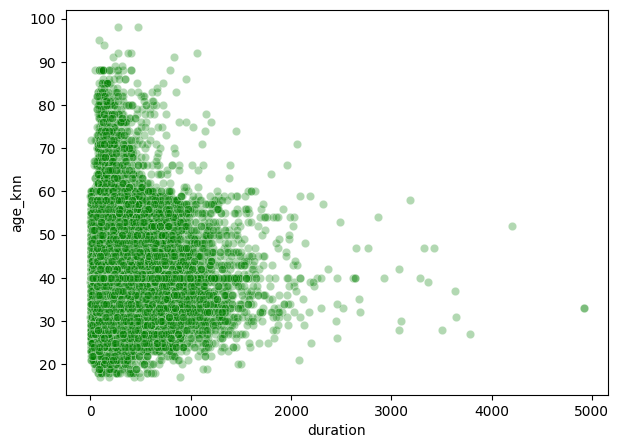

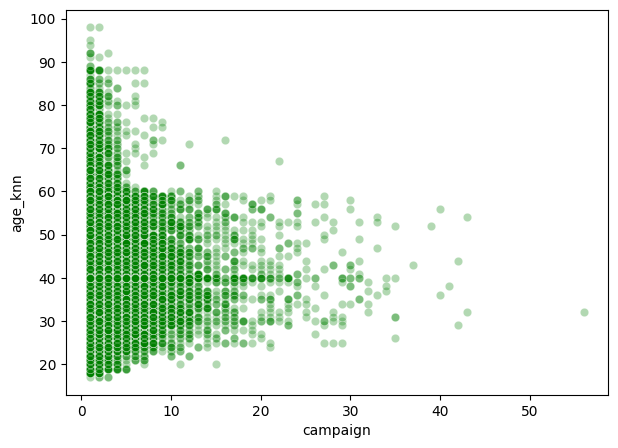

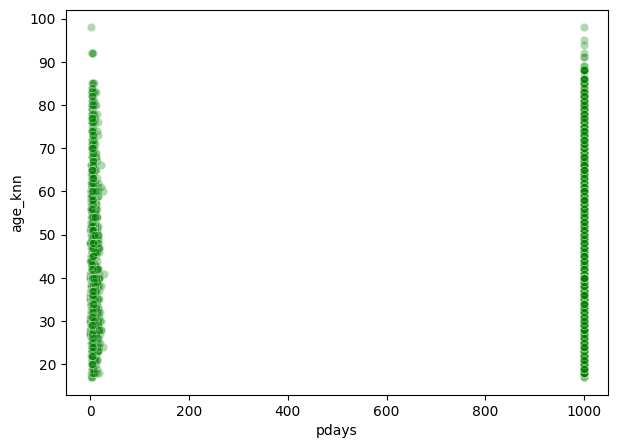

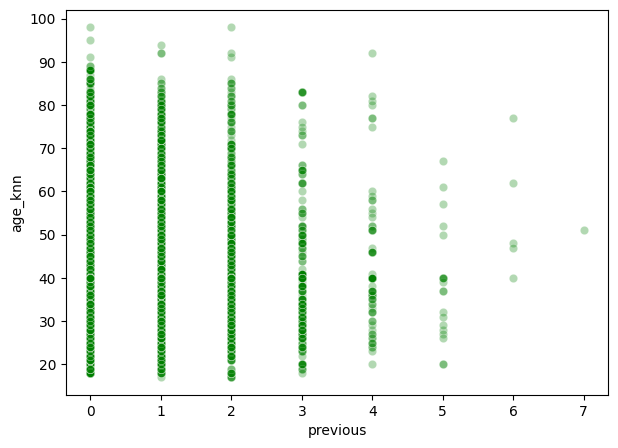

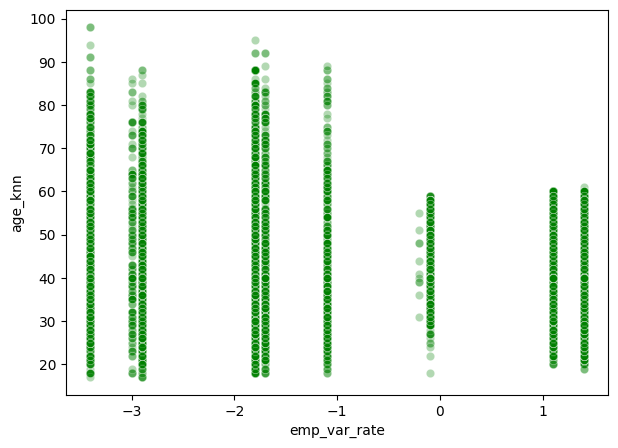

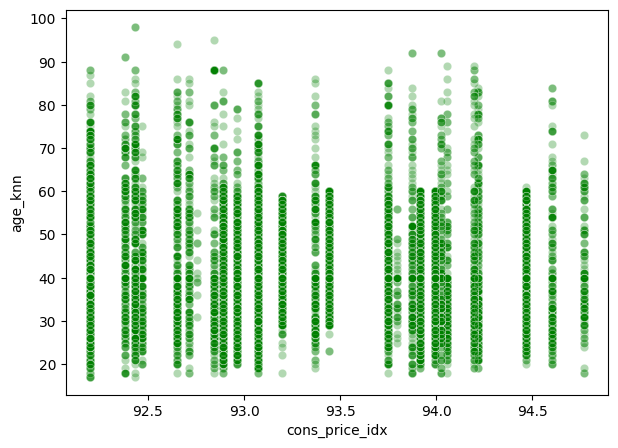

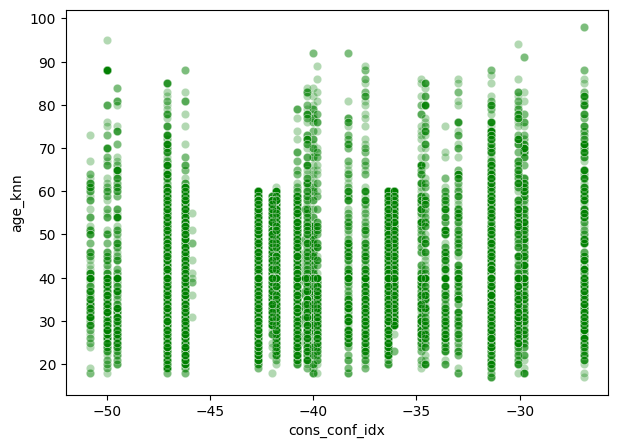

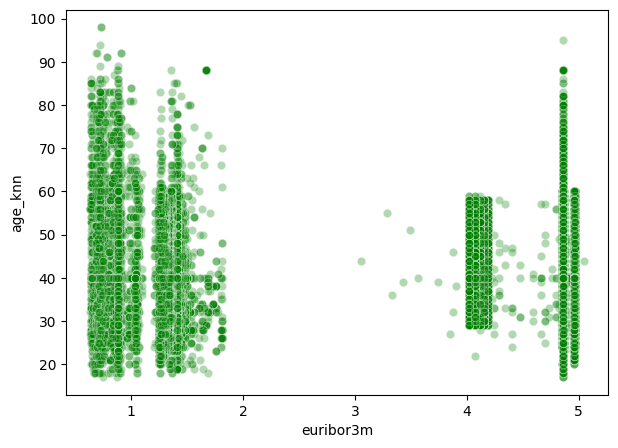

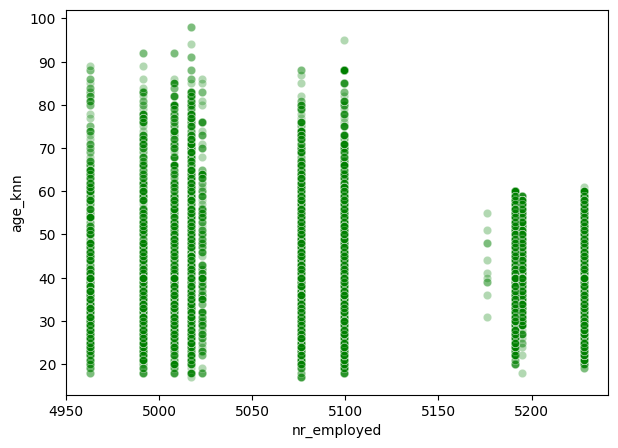

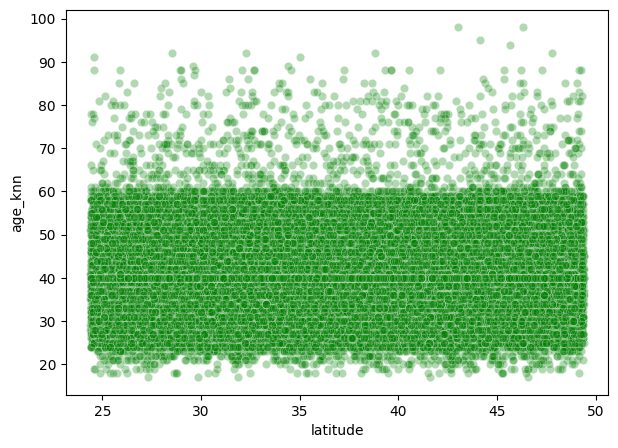

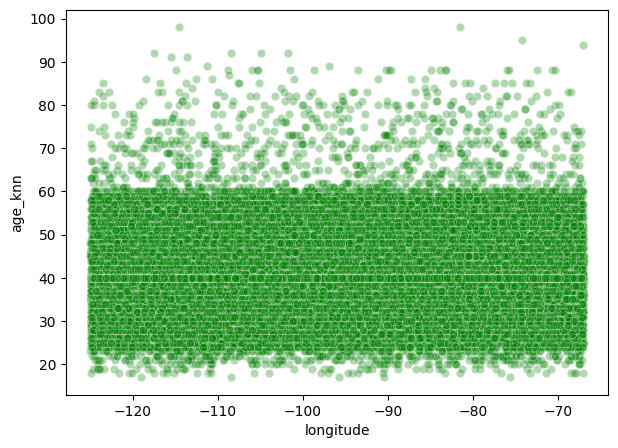

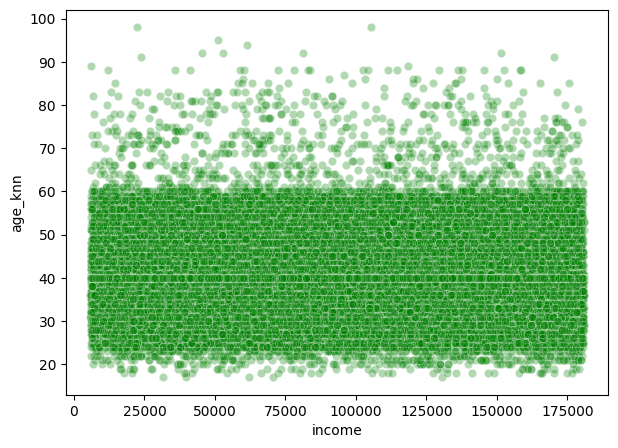

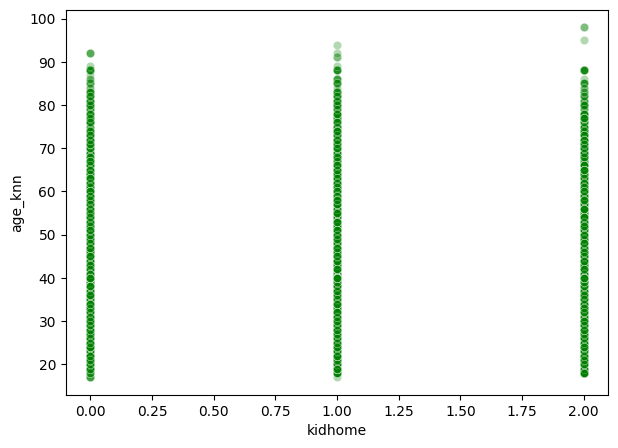

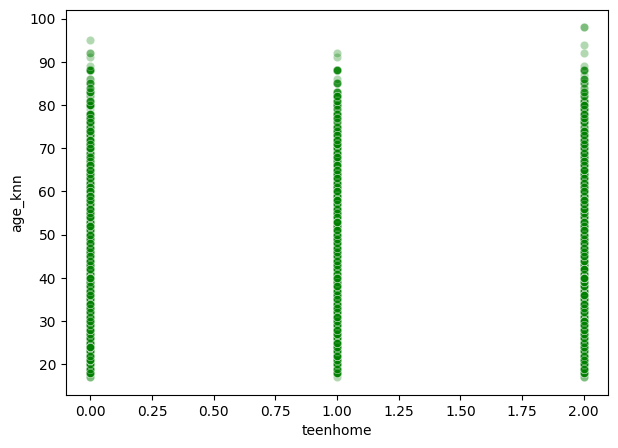

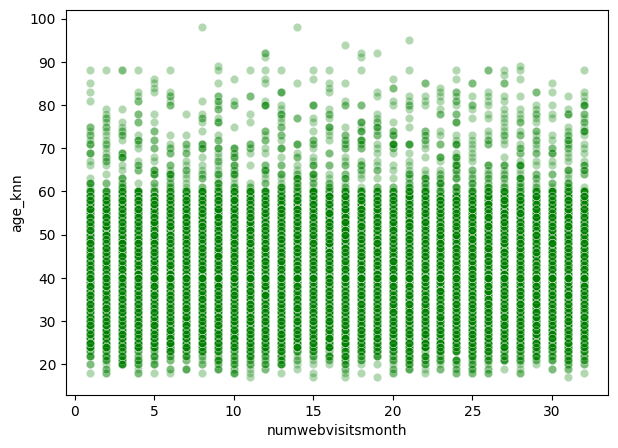

In [22]:
for col in cols_num:
    if col == col_num:
        continue
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=df_no_nulos, x= col, y=col_num, color= 'green', alpha= 0.3)
    #plt.yscale('log')
    plt.show()

### COLUMNAS CATEGORICAS

In [18]:
df_no_nulos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   job                43000 non-null  object 
 1   marital            43000 non-null  object 
 2   education          43000 non-null  object 
 3   default            34019 non-null  float64
 4   housing            41974 non-null  float64
 5   loan               41974 non-null  float64
 6   contact            43000 non-null  object 
 7   duration           43000 non-null  int64  
 8   campaign           43000 non-null  int64  
 9   pdays              43000 non-null  int64  
 10  previous           43000 non-null  int64  
 11  poutcome           43000 non-null  object 
 12  emp_var_rate       43000 non-null  float64
 13  cons_price_idx     43000 non-null  float64
 14  cons_conf_idx      43000 non-null  float64
 15  euribor3m          43000 non-null  float64
 16  nr_employed        430

In [7]:
col_num = 'age_knn'

cols_cat = df_no_nulos.select_dtypes(include=['category','object']).columns


cols_cat

Index(['job', 'marital', 'education', 'contact', 'poutcome',
       'subscription_prod', 'date_contact', 'dt_customer', 'id', 'default_str',
       'housing_str', 'loan_str'],
      dtype='object')

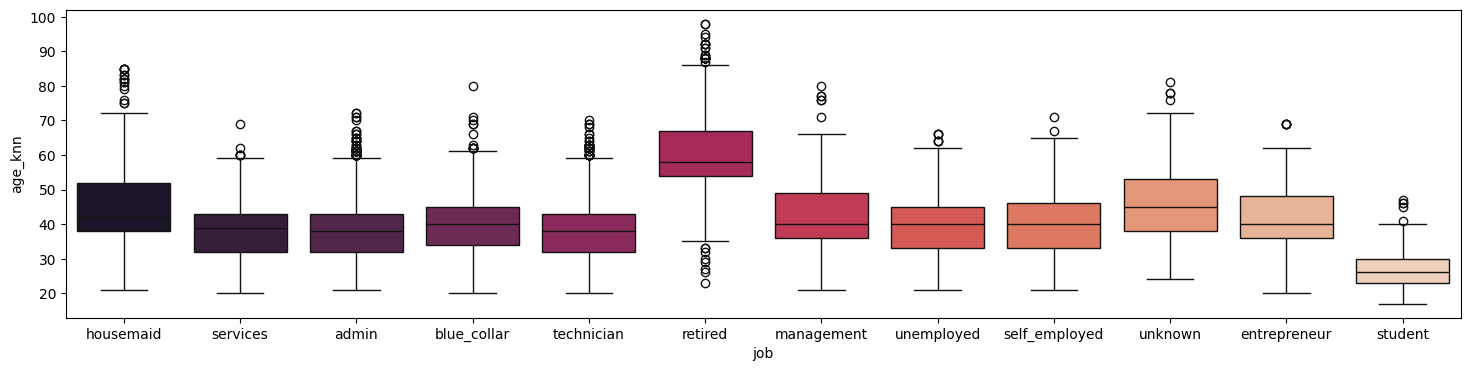

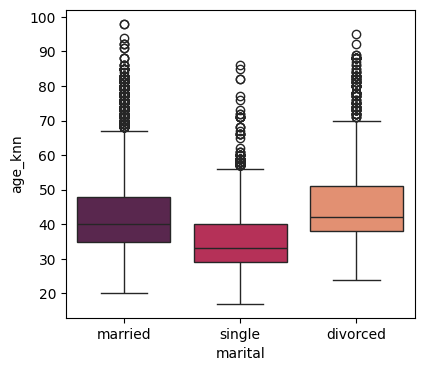

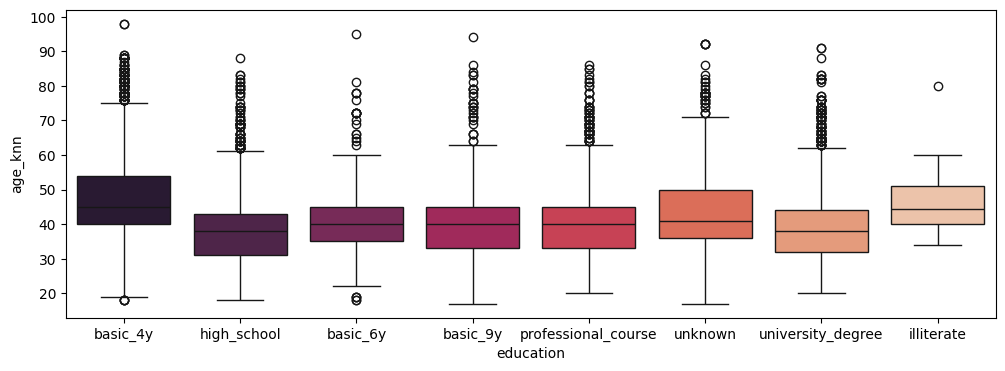

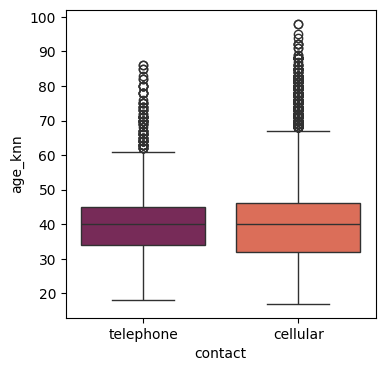

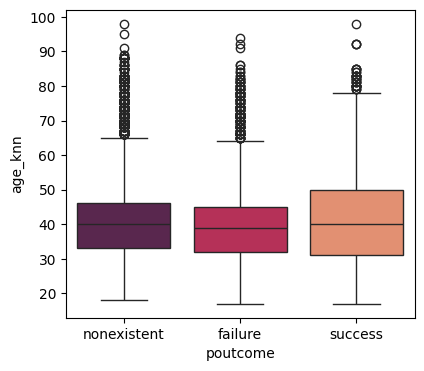

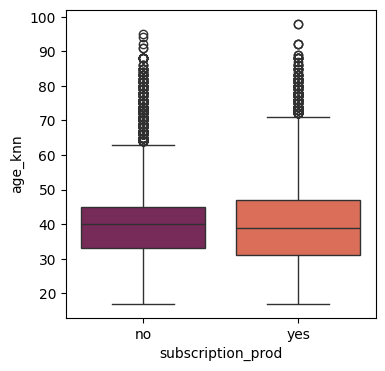

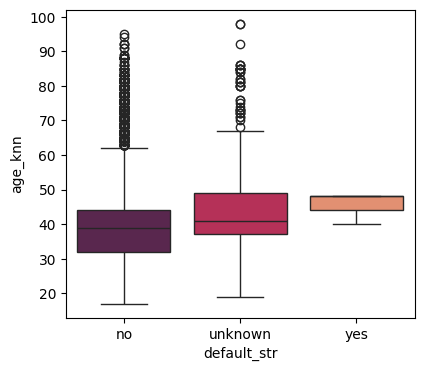

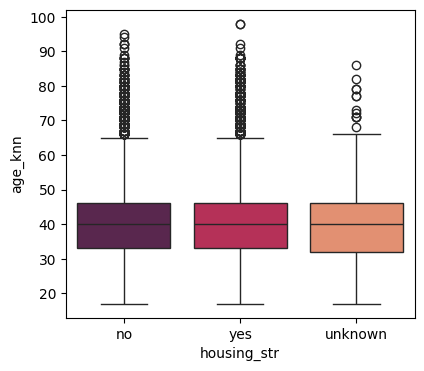

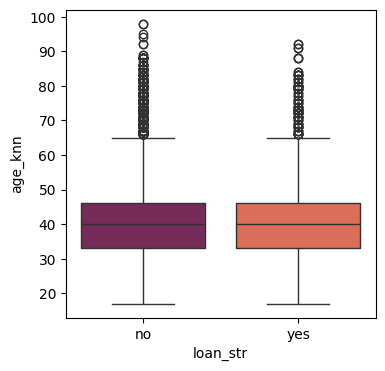

In [19]:
col_num = 'age_knn'

cols_cat = df_no_nulos.select_dtypes(include=['category','object']).columns

for col in cols_cat:
    if col=='date_contact':
        continue
    if col=='dt_customer':
        continue
    if col=='id':
        continue
    # calcular el numero de categorias unicas
    num_cats = df_no_nulos[col].nunique()
    
    # Ajustar dinamicamente el tamaño del grafico
    fig_width = max(4, num_cats * 1.5)
    fig_height = 4

    cats_ordenadas = df_no_nulos.groupby(col)[col_num].mean().sort_values().index # para odernar en este caso por edad
    plt.figure(figsize=(fig_width, fig_height))
    sns.boxplot(x=df_no_nulos[col], y=df_no_nulos[col_num],hue=df_no_nulos[col], palette='rocket') # order = cats_ordernadas (si queremos ordenar por edad)
    plt.show()
    
   

    